# Lecture 11

## Intro to Deep learning using Pytorch

 PyTorch provides **tensors**, which are similar to NumPy arrays but can also live on GPUs for fast computation. 
    GPUs are graphic cards, summing specific row 
- PyTorch provides **automatic differentiation** (`autograd`), which makes it possible to compute gradients needed for training neural networks.
- PyTorch provides the `nn.Module` framework for defining neural networks as Python classes.
- PyTorch also provides tools for **datasets** and **data loaders**, which help organize training data and iterate over it in batches.

### Import packages 

- To install PyTorch in your environment, first activate the environment and then use pip.
- Check the PyTorch website for the exact installation command [https://pytorch.org/get-started/locally/](https://pytorch.org/get-started/locally/)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# To isntall torch in your envirnment use pip after activating your envirnment.
# CHekc this url for exact command

import torch
import torch.nn as nn #module mostly will interact with, to build own neural network 
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import warnings
warnings.filterwarnings('ignore')

The "XOR" (or "exclusive OR") problem is often used to illustrate the ability of neural networks to fit complicated functions. The XOR problem has a checkerboard structure:

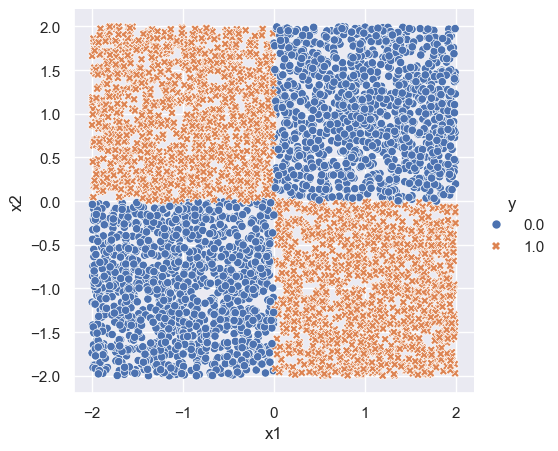

In [6]:
# xor ------------------------------------
# generate synthetic data, two features for observations, 2 columns 5000 rows 
# x is a uniform random variable between -2 and 2, size is 5000 rows by 2 columns 
n = 5000
p = 2
x = np.random.uniform(-2, 2, size=(n, p))

y = ((x[:,0] < 0) & (x[:, 1] > 0)).astype(x.dtype) + ((x[:,0] > 0) & (x[:, 1] < 0)).astype(x.dtype)

# if column 1 is smaller than 0 and the second feature is greater than 0, gives true or false, 
# but then we transform them into the same type as the number 

#logistic regression is not the best model for this data because you cannot have nuianced type of relationship 
#one for one value and zero for the same value later 


df = np.hstack([y.reshape((n, 1)), x])
df = pd.DataFrame(df, columns = ['y', 'x1', 'x2'])

sns.set_theme()
xor_plot = sns.relplot(df, x='x1', y='x2', hue='y', style='y')
plt.subplots_adjust(top=.9)

Logistic regression can only fit linear decision boundaries, and so fails the XOR problem.

In [7]:
# Fit logistic regression
log_fit = LogisticRegression()
log_fit.fit(x, y)

# Predictions
y_prob = log_fit.predict_proba(x)[:,1] #take predictive probability 
y_pred = log_fit.predict(x) # or just take the predicted class right away 

# Data for plotting
df_plot = df.copy()
df_plot["y_pred"] = y_pred

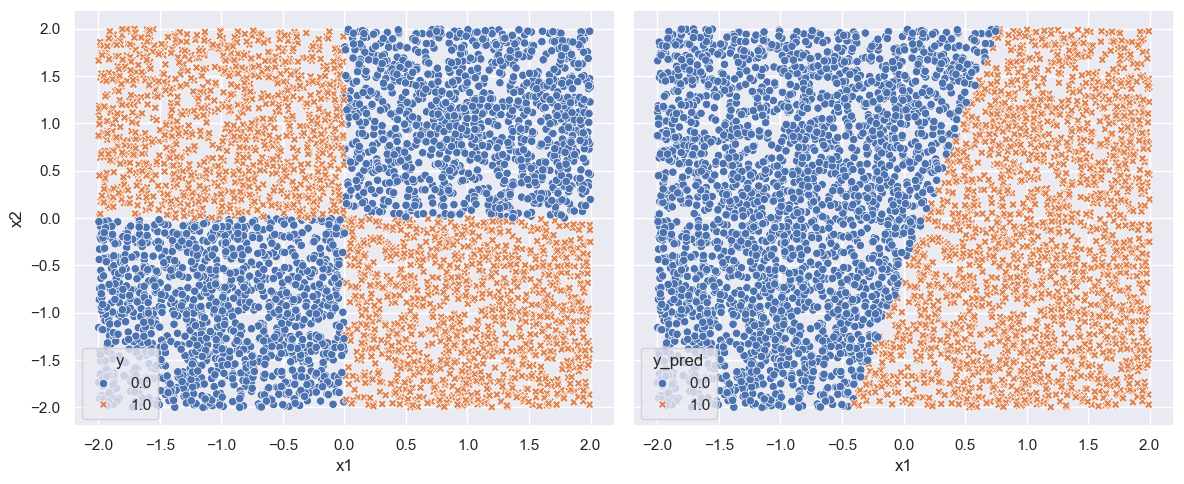

In [8]:
# Plot
sns.set_theme()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Left: true labels
sns.scatterplot(
    data=df_plot, x="x1", y="x2", hue="y", style="y", ax=axes[0]
)

# Right: predicted labels
sns.scatterplot(
    data=df_plot, x="x1", y="x2", hue="y_pred", style="y_pred", ax=axes[1]
)


plt.tight_layout()
plt.show()

#the best the linear regression can do is create a linear boundary, there is no possible linear boundary that can predict this well 


### Feed-forward fully connected neural networks

Most basic neural networks are built by stacking linear transformations and fixed nonlinear activation functions such as the sigmoid, ReLU, or tanh.

Single hidden layer NN: 

$$
f_{\theta}(x) = f_{W_2, W_1, b_1, b_2}(x) = \sigma\left( W_2 \, \sigma(W_1 x + b_1) + b_2 \right),
$$
where $\sigma(x) = \sigma(x) = \frac{1}{1 + e^{-x}}$

introduces linear layer, similar to linear regression, p dimensional matrix to a q dimensional matrix
dont compress information to one scale 
applies non linear transformation 
repeats the operation several times 

### Fitting to the data

can write this into two steps 

Expanded expression:

$$
h_j = \sigma\left( \beta_{j0} + \beta_{j1}x_1 + \cdots + \beta_{jp}x_p \right), \qquad j=1,\dots,m
$$
stoping here would be just a linear regression 
$$
f(x) = \sigma\left( \alpha_0 + \alpha_1 h_1 + \cdots + \alpha_m h_m \right)
$$

gives a value between 0 and 1 and use that as predictive probability 

Given a training set $(y_i, x_i)$, neural network are fit to the data by minimizing a **loss function**

$$
\hat{\theta} = \arg\min_{\theta} \sum_{i=1}^n L\big(y_i, f_{\theta}(x_i))\big)
$$

<div style="text-align: center;">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTNqdh7oprmD-9ilwB-_dajI17FWHDAA9rX1Q&s" width="200">
</div>

each one of these nodes is a variable 
there are three input variables (height weight age)
find intermediate variable (4 in this case) each combination of the nodes plus sigma? or some measure of non linear 
then the output is based on the intermediate variables 



### Pytorch: building blocks

PyTorch defines `nn.Linear`, which allows linear transformation $$y = xA^T + b$$ in an object-oriented style.

pytorch define neural network looks like through layers 

add bias term to get output 

if wanted to go from 2 to 3 dimensions then the tensor a becomes 2 x 3

In [ ]:
linear_layer = nn.Linear(in_features = 2, out_features = 1)
#layer with linear transformation that takes in 2 features and outputs 1 feature, so it is a linear regression layer
#nn.linear is a class 
#specify input and output features 
print(f"A: {linear_layer.weight}\n") # This is the matrix A, initialized at random
#parameter weight is a pytorch array, tensor 
print(f"b: {linear_layer.bias}\n") # This is the vector b, initialized at random

#transform data into tensor 
x_train = torch.tensor(x, dtype=torch.float)
y_train = torch.tensor(y, dtype=torch.float)

#apply linear layer 
#Equal to: x_train@linear_layer.weight.T + linear_layer.bias
output_linear = linear_layer(x_train)
print(f"xA^T + b:\n {output_linear}")

#simple way to apply nonlinearity is to apply a function to the output of the linear layer

#will take the tensor A and apply bias to it 


A: Parameter containing:
tensor([[-0.6296, -0.0093]], requires_grad=True)

b: Parameter containing:
tensor([-0.5850], requires_grad=True)

xA^T + b:
 tensor([[-0.0474],
        [-0.7182],
        [-0.9230],
        ...,
        [-0.2452],
        [ 0.0403],
        [ 0.4270]], grad_fn=<AddmmBackward0>)


PyTorch defines `nn.Sigmoid`, which applies the sigmoid transformation in an object-oriented style.

In [12]:
sigmoid_layer = nn.Sigmoid()

# Equivalent to applying the sigmoid function elementwise:
# sigma(z) = 1 / (1 + exp(-z))
output_sigmoid = sigmoid_layer(output_linear)
y_pred = output_sigmoid.flatten()

print(f"\sigma(xA^T + b):\n {y_pred}")

#if you stop here you get first part of logisitc regression 

\sigma(xA^T + b):
 tensor([0.4882, 0.3278, 0.2843,  ..., 0.4390, 0.5101, 0.6051],
       grad_fn=<ViewBackward0>)


Check fit to the data. PyTorch defines several loss functions. This is a classification problem, so we use the same loss function as logistic regression (Binary Cross Entropy loss)

$$
\ell(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \right]
$$

In [ ]:
#difference between our prediction and true value of the data 


loss_fn = torch.nn.BCELoss(reduction="sum") # Binary Cross Entropy loss, checks how far your predictions are from true values


loss = loss_fn(y_pred, y_train)
# y train are the true observations, y pred are the predicted values, 
# so this is how far our predictions are from the true values

print(f"Loss value is: {loss.item()}")

#predictions are not good because they are based on weights determined at random, 
# we have not trained the model yet, so we have not updated the weights to minimize the loss,
#  so the predictions are not good at this point

Loss value is: 4009.494384765625


### Gradient-based minimization

Neural networks are typically fit using **gradient descent** or one of its variants.

Starting from an initial guess $\theta^{(0)}$, gradient descent updates the parameters iteratively according to

$$
\theta^{(t+1)} = \theta^{(t)} - \eta \nabla \left[ \sum_{i=1}^n L\big(y_i, f(x_i; \theta^{(t)})\big) \right]
$$

where $\eta > 0$ is the **learning rate** and $\nabla$ denotes the gradient with respect to the parameters. The gradient points in the direction of steepest increase of the loss, so subtracting it moves the parameters in a direction that reduces the loss.

principal way of making loss function smaller, 
the gradient of the objective function is an object of the same size of the parameter 
will be a vector of the same dimension of how many weights i have 
subtract gradient from the current parameters 

**What is so powerful about PyTorch? Automatic gradient computation.**

In [27]:
loss = loss_fn(y_pred, y_train)
loss.backward() # This command allows you to compute the gradient of all unkown parameters
# matrix of how to update the weights to make the loss smaller 
# can be automated because the objective function is just a composition of functions, 
# so we can use the chain rule to compute the gradient of the loss with respect to the weights and bias, 
# and then we can use that gradient to update the weights and bias in the direction that minimizes the loss

print(f"Gradient for weight linear module: {linear_layer.weight.grad}")
print(f"Gradient for bias linear module: {linear_layer.bias.grad}")


Gradient for weight linear module: tensor([[-4.6244e+02, -2.4852e-01]])
Gradient for bias linear module: tensor([-383.0183])


In [ ]:
# Manual gradient descent step. Idea update weight in the direction suggested by gradients.
learning_rate = 0.0001

with torch.no_grad():  #tells PyTorch not to track gradients for the operations inside that block (gradients have already been computed by now)
    linear_layer.weight -= learning_rate * linear_layer.weight.grad
    linear_layer.bias -= learning_rate * linear_layer.bias.grad

# Clear gradients before next backward pass
linear_layer.weight.grad = None
linear_layer.bias.grad = None

# Recompute predictions after the update
output_linear = linear_layer(x_train)
output_sigmoid = sigmoid_layer(output_linear)
y_pred = output_sigmoid.flatten()

loss = loss_fn(y_pred, y_train)
print(f"Loss after update is: {loss.item()}")

# Idea: Repeat this step procedure iteratively 
#  - Compute gradient
#  - Update paramters
# until loss function reaches ``small'' stable value

# Try it for yourself (keep running the last two blocks)

#doing this with new weights that have been updated with gradients
#has become smaller, but we would typically do this on a loop and keep updating the weights until the loss is small enough,
#the learning rate is a trade off, you want it small enough then you will 

Loss after update is: 3557.531494140625


### How to best use PyTorch: Define a class for your neural network

The code above was meant only to illustrate the basic idea. In practice, PyTorch code is usually organized by defining a class that combines all the operations of a neural network into a single object.

When we define a neural network in PyTorch, we typically create a **subclass** of `nn.Module`. In other words, our class **inherits** from `nn.Module`.

By inheriting from `nn.Module`, our class gets useful built-in behavior, such as:

- storing model parameters
- working with optimizers
- switching between training and evaluation mode
- integrating naturally with the rest of PyTorch

This is a good example of **inheritance**: we build our own class on top of an existing one.

Here is an example of a neural network in `torch` called `XORNet`.

In [30]:
# Single hidden layer neural network

class XORNet(nn.Module): # Name of the class (neural network model) inheriting nn.Module
    #this neural network builds on top of code built on from pytorch 

    def __init__(self, input_dim, hidden_dim): # Initializer (think of hyperparamters as in scikit learn)
        super(XORNet, self).__init__() # Call initializer of nn.Module, do the things i tell you to do but on top of it take the nn.module 
        #this is standard, just copy and paste it 

        #input dim is the number of features, hidden dim is the number of neurons in the hidden layer
        

        #define layers of the neural network, these are the parameters that will be updated during training
        self.linear1 =  nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, 1) #second layer takes hidden dim as input and outputs 1 feature, 
        #so it is a linear regression layer
        self.sigmoid = nn.Sigmoid() #nonlinearity, this is not a parameter that will be updated during training, 
        #it is just a function that we will apply to the output of the linear layers to introduce nonlinearity into the model, 
        # without this the model would just be a linear regression model, so we need this to be able to learn more complex 
        # relationships in the data

        #these are the modules that we will use to build our neural network, 
        # we will use them in the forward function to define how the data flows through the network
        

        #define the input data onto output vector that is 5000 x 1 

    def forward(self, x):  # The function `forward` is called when the neural network is run on input data.
        out_1 = self.linear1(x) # output is samples x 1 matrix, take intermediate variable 
        out_2 = self.sigmoid(out_1) # take out 1 and add sigmoid
        out_3 = self.linear2(out_2) # take out 2 and add linear layer, output is samples x 1 matrix
        out_4 = self.sigmoid(out_3) # take out 3 and add sigmoid, output is samples x 1 matrix, this is the final output of the network,
        y = torch.flatten(out_4) # output is samples vector
        return y
    
    #take my data apply linear transformation, non linear, linear, non linear then give me output 

In [31]:
hidden_dim=10
model = XORNet(input_dim=p, hidden_dim=hidden_dim)

In [ ]:
model

#create object model 


XORNet(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Apply to data:

In [33]:
x_train = torch.tensor(x, dtype=torch.float)
y_train = torch.tensor(y, dtype=torch.float)

In [ ]:
loss_fn = torch.nn.BCELoss(reduction="sum") 

# Apply nueral network (with random weights to data)
ypred = model(x_train)
cur_loss = loss_fn(ypred, y_train)
print(ypred.shape)
print(cur_loss)

#have not trained the model yet
# this is meant to show how you train neural network 

torch.Size([5000])
tensor(4035.2188, grad_fn=<BinaryCrossEntropyBackward0>)


### Data: Best practice is to use `TensorDataset` and `DataLoader`

We combine `x_train` and `y_train` into a `TensorDataset`, a dataset recognizable by torch. `TensorDataset` stores the samples and their labels. It is a subclass of the more general `torch.utils.data.Dataset`, which you can customize for non-standard data.

In [ ]:
train_data = TensorDataset(x_train, y_train)
#object puts together predicttors and outcomes into one object 
#creates tupples for each subject 


In [91]:
x_temp, y_temp = train_data[0]

In [92]:
x_temp

tensor([-1.8389, -1.9797])

`TensorDataset` is helpful as it can be passed to `DataLoader()`. `DataLoader` wraps an iterable around the `Dataset` class to enable easy access to the samples. This is very helpful for implementing stochastic gradient descent, where we iterate over subsets (batches) of the data.

This allows you to easily implement stochastic gradient descent, where the idea is to compute gradients from subsets of your data and introduce randomness that can help escape local minima.

In [ ]:
train_loader = DataLoader(dataset=train_data, batch_size=10, shuffle=True)

#batch size is split data into 10 parts 

### Training
We now set up the optimizer for training. We use Adam, and a base learning rate of `lr=0.01`. We set the number of epochs to 100. (Rule of thumb: pick largest `lr` that still results in convergence)

In [ ]:
#need to specify the device we want to run our model on, this is important for 
# training because if we have a gpu available we want to use it to speed up training,

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use cpu or gpu based on whether the latter is available

#specify learning rate how fast you want it to learn 
lr = 0.01 # learning rate

#how long do you want to keep updating the weights, how many times do you want to go through the whole dataset and update the weights,
epochs = 300 # How many passes of the full dataset (think "iterations of gradient descent")

optimizer = optim.Adam(model.parameters(), lr=lr) 
loss_bce = torch.nn.BCELoss(reduction="sum") 


# set model to training mode
model.train()
#tell model get ready to be trained 




XORNet(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Now we train the model:

In [ ]:
#for loop makes a little update and check to see what the loss is after the update 

for epoch in range(epochs):
    
    # in each epoch, iterate over all batches of data (easily accessed through train_loader)
    epoch_loss = 0

    for x_batch, y_batch in train_loader:

        # calculate gradient over batch

        pred = model(x_batch)                   # this is the output from the forward function
        loss = loss_bce(pred, y_batch)           # calculate loss function

        loss.backward()                         # computes gradients wrt loss function

        # update parameters in direction of gradient

        optimizer.step()                        # updates parameters 

        optimizer.zero_grad()                   # set the gradients back to zero (otherwise grads are accumulated)

        epoch_loss += loss.item()               # grabs just numeric value of loss

    if epoch % 10 == 0:
        print('epoch: ', epoch, 'loss:', f"{epoch_loss:.3}")

        #only print every 10 epochs to avoid too much output, 
        # but you can print every epoch if you want to see the loss decrease more clearly


epoch:  0 loss: 3.03e+03
epoch:  10 loss: 4e+02
epoch:  20 loss: 2.7e+02
epoch:  30 loss: 1.98e+02
epoch:  40 loss: 1.67e+02
epoch:  50 loss: 1.52e+02
epoch:  60 loss: 1.42e+02
epoch:  70 loss: 1.33e+02
epoch:  80 loss: 1.26e+02
epoch:  90 loss: 1.22e+02
epoch:  100 loss: 1.17e+02
epoch:  110 loss: 1.12e+02
epoch:  120 loss: 1.08e+02
epoch:  130 loss: 1.07e+02
epoch:  140 loss: 1.07e+02
epoch:  150 loss: 1.02e+02
epoch:  160 loss: 1e+02
epoch:  170 loss: 99.2
epoch:  180 loss: 99.3
epoch:  190 loss: 95.4
epoch:  200 loss: 95.7
epoch:  210 loss: 92.0
epoch:  220 loss: 89.8
epoch:  230 loss: 91.2
epoch:  240 loss: 88.5
epoch:  250 loss: 91.9
epoch:  260 loss: 85.9
epoch:  270 loss: 87.8
epoch:  280 loss: 82.8
epoch:  290 loss: 85.0


To visualize the end result, we plot the predicted values over the whole space (the decision surface).

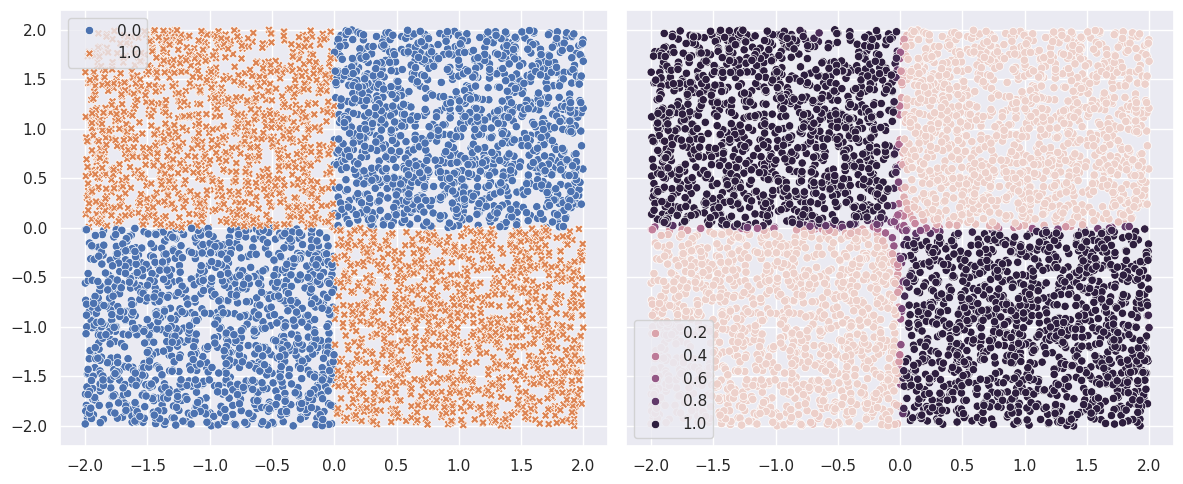

In [ ]:
x1 = np.arange(-2, 2, 0.05)
x2 = np.arange(-2, 2, 0.05)

#moved away from training into evaluation mode 

model.eval() # Make it clear that you are doing with training
y_pred = model(x_train) # Evaluate data
y_pred_prob_np = y_pred.detach().numpy() #covert into a numpy vector 
y_pred_label_np = y_pred_prob_np>0.5 


sns.set_theme()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Left: true labels
sns.scatterplot(
    x=x[:,0], y=x[:,1], hue=y, style=y, ax=axes[0]
)

# Right: predicted labels
sns.scatterplot(
    x=x[:,0], y=x[:,1], hue=y_pred_prob_np, ax=axes[1]
)


plt.tight_layout()
plt.show()

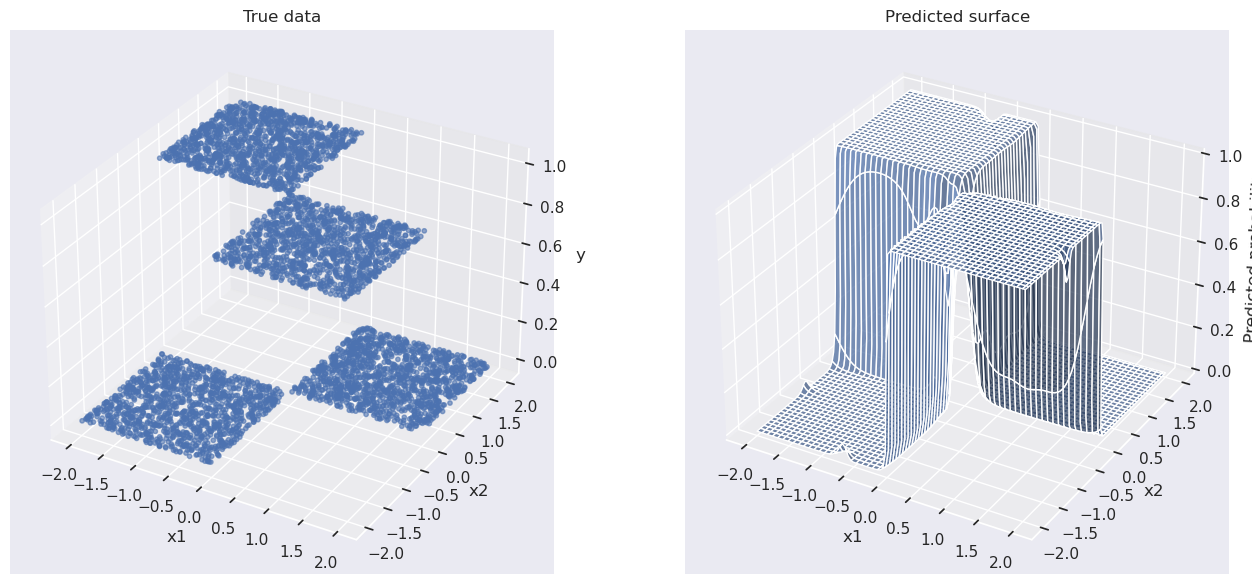

In [60]:
# 3D version of the same plot

fig = plt.figure(figsize=(14, 6))

# Left panel: true data
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(
    x[:, 0],
    x[:, 1],
    y,
    s=10,
    alpha=0.6
)
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("y")
ax1.set_title("True data")

# Create grid over x1-x2 space
x1_grid = np.linspace(x[:, 0].min(), x[:, 0].max(), 100)
x2_grid = np.linspace(x[:, 1].min(), x[:, 1].max(), 100)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

grid = np.column_stack([X1.ravel(), X2.ravel()])

# Predict on grid
# If using sklearn:
Z = model(torch.tensor(grid, dtype=torch.float)).detach().numpy()

# If using PyTorch instead, use something like:
# with torch.no_grad():
#     grid_tensor = torch.tensor(grid, dtype=torch.float32).to(device)
#     Z = model(grid_tensor).detach().cpu().numpy()

Z = Z.reshape(X1.shape)

# Right panel: predicted surface
ax2 = fig.add_subplot(122, projection="3d")
ax2.plot_surface(
    X1, X2, Z,
    alpha=0.7
)
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("Predicted probability")
ax2.set_title("Predicted surface")

plt.tight_layout()
plt.show()

Play around with different sizes of `hidden_dim` and see the difference!